# Overlap and divergence of anomaly scores

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [3]:
se_cols = [
    'mse',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_97',
    # 'mse_95',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

se_rank_cols = [
    f"rank_{col}" for col in se_cols
]

# ----------------------------------------------
rse_cols = [
    f"{col}_rel" for col in se_cols
]

rse_rank_cols = [
    f"rank_{col}_rel" for col in se_cols
]
# ----------------------------------------------
se_family = [
    'mse',
    'mse_97',
    # 'mse_95',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

rse_family = [
    f'{col}_rel' for col in se_family
]

# Custom functions

## SDSS photometry

In [4]:
def get_sdss_spec_img(
    specobjid, ra, dec, save_to
    ):
    """Download sdss image and spectrum"""

    meta.download_sdss_spectrum_image(
        specobjid=specobjid,
        save_to=save_to,
        image_format="jpeg",
    )

    meta.get_sdss_image(
        specobjid,
        coordinates= (ra, dec),
        save_to=save_to,
        image_format="jpeg",
    )

## thumbnails

In [5]:
def spec_photo_thumbnail(
    ax,
    wave, spec,
    photo_img=None,
    width_height_image='100%',
    bbox_to_anchor=(0.695, 0.52, 0.5, 0.5),
    add_image=False,
):

    ax.plot(wave, spec, color='black')
    # Create inset in top-right corner of figure

    ax.set_xlim(350, 770)
    wave_ticks = list(np.arange(400, 751, 50))
    ax.set_xticks(wave_ticks)

    if add_image is False:
        return ax, None

    axins = inset_axes(
        ax,
        width=width_height_image, height=width_height_image,
        bbox_to_anchor=bbox_to_anchor,
        bbox_transform=ax.transAxes,
    )

    # Show image in the inset
    axins.imshow(photo_img)
    axins.axis('off')  # Hide axis around the image

    return ax, axins


## Line indicators

In [6]:
GALAXY_LINES_NM = {
    'OII': {'name': 'OII', 'line_wave': 372.7},
    # 'NeIII': {'name': 'NeIII', 'line_wave': 386.9},
    # 'HI': {'name': 'HI', 'line_wave': 388.9},
    'H_epsilon': {'name': r'H$\epsilon$', 'line_wave': 397},
    'H_delta': {'name': r'H$\delta$', 'line_wave': 410.2},
    'H_gamma': {'name': r'H$\gamma$', 'line_wave': 434.0},
    'H_beta': {'name': r'H$\beta$', 'line_wave': 486.1},
    'OIII': {'name': 'OIII', 'line_wave': 500.7},
    'H_alpha': {'name': r'H$\alpha$', 'line_wave': 656.3},
    'SII': {'name': 'SII', 'line_wave': 673},
    # 'SII': 671.6
}

In [80]:
def add_line_indicators(
    ax, wave, spec,
    indicator_starts,
    indicator_height,
    add_oii=False,
    add_ne3_he1=False,
    add_h_epsilon=False,
    add_h_delta=False,
    add_h_gamma=False,
    add_oiii=False,
    add_h_beta=False,
    add_sii=False,
    delta=1,
    indicator_color='blue',
    indicator_label_color='black',
    lw=1.5,
    fontsize=8,
):
    
    for line_name, value_dict in GALAXY_LINES_NM.items():
        
        # skip desired lines
        if line_name == 'OII' and add_oii is False:
            continue

        if line_name == 'H_epsilon' and add_h_epsilon is False:
            continue

        if line_name == 'H_delta' and add_h_delta is False:
            continue

        if line_name == 'H_gamma' and add_h_gamma is False:
            continue

        if line_name == 'H_beta' and add_h_beta is False:
            continue

        if line_name == 'OIII' and add_oiii is False:
            continue

        if line_name == 'SII' and add_sii is False:
            continue

        line_wave = value_dict['line_wave']
        # Find the flux value of the spectrum at the line's wavelength
        # get small neigborhood among line_wave
        # get max flux there and set as line_flux
        line_flux = np.max(
            spec[(wave > line_wave - delta) & (wave < line_wave + delta)]
        )

        # Plot vertical line indicator
        y_start_indicator = line_flux + indicator_starts
        y_end_indicator = y_start_indicator + indicator_height

        ax.plot(
            [line_wave, line_wave], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        
        clean_name = value_dict['name']

        y_text_start = y_end_indicator + indicator_height/2

        ax.text(
            line_wave, 
            y_text_start, 
            clean_name,
            ha='center', va='bottom', 
            fontsize=fontsize, rotation=90, 
            color=indicator_label_color
        )

        # doubles manual setup
        if line_name == 'OIII':
            ax.plot(
                [495.9, 495.9], 
                [y_start_indicator, y_end_indicator], 
                color=indicator_color, lw=lw
            )

        if line_name == 'H_alpha':

            y_nii_start = y_start_indicator - indicator_height/2
            y_nii_end = y_end_indicator - indicator_height/2

            # NII 1st
            ax.plot(
                [654.8, 654.8],
                [y_nii_start, y_nii_end],
                color=indicator_color, lw=lw
            )
            y_nii_text = y_nii_end + indicator_height/2
            ax.text(
                649, y_nii_text,
                'NII',
                ha='center', va='bottom', 
                fontsize=fontsize, rotation=90, 
                color=indicator_label_color
            )

            # NII 2nd
            ax.plot(
                [658.3, 658.3], 
                [y_nii_start, y_nii_end], 
                color=indicator_color, lw=lw
            )

            ax.text(
                664.1, y_nii_text,
                'NII',
                ha='center', va='bottom', 
                fontsize=fontsize, rotation=90, 
                color=indicator_label_color
            )

        if line_name == 'SII':
            ax.plot(
                [671.6, 671.6],
                [y_start_indicator, y_end_indicator], 
                color=indicator_color, lw=lw
            )

    # optionally add NeIII-1 and He I
    if add_ne3_he1 is True:

        line_flux = np.max(
            spec[(wave > 386.9 - delta) & (wave < 388.9 + delta)]
        )
        y_start_indicator = line_flux + indicator_starts
        y_end_indicator = y_start_indicator + indicator_height

        # add indicator for NeIII 386.9
        ax.plot(
            [386.9, 386.9], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        # add indicator for HI 388.9
        ax.plot(
            [388.9, 388.9], 
            [y_start_indicator, y_end_indicator], 
            color=indicator_color, lw=lw
        )
        # add label NeIII + He I
        y_text_start = y_end_indicator + indicator_height/2

        ax.text(
            387.9, 
            y_text_start, 
            'NeIII + HeI',
            ha='center', va='bottom', 
            fontsize=fontsize, rotation=90, 
            color=indicator_label_color
        )

    return ax

## IDs top anomalies

In [8]:
def get_ids_set(score, df, quantile=99, n_top=None, use_ntop=False):

    if use_ntop is False:
        
        quantile *= 0.01
        thresh = df[score].quantile(quantile)
        ids = set(df[df[score] > thresh].index)
        
    else:

        ids = set(
            df[score].sort_values(
                ascending=False
            ).iloc[:n_top].index
        )

    return ids

In [9]:
def top_unique_ids(scores_df, scores_list, quantile=99, n_top=None, use_ntop=False):

    ids_top_dict = {}

    ids_top_list = []

    for score in scores_list:

        ids_set = get_ids_set(
            score=score,
            df=scores_df,
            quantile=quantile,
            n_top=n_top,
            use_ntop=use_ntop
        )

        ids_top_dict[score] = ids_set

        ids_top_list += list(ids_set)


    n_dictinct_top = len(set(ids_top_list))

    print(f"N unique: {n_dictinct_top}")


    unique_ids_dict = AnomalyOverlapAnalyzer.get_unique_ids(
        ids_dict=ids_top_dict, score_list=scores_list
    )

    for score in scores_list:
        n_unique = len(unique_ids_dict[score])

        unique_pct = n_unique/n_dictinct_top*100
        
        print(f"Unique to {score}:\n{n_unique} --> {unique_pct:.4f}%")

    return unique_ids_dict, ids_top_dict, n_dictinct_top


In [10]:
def top_common_ids(scores_df, scores_list, quantile=99, n_top=None, use_ntop=False):

    ids_top_dict = {}
    ids_top_list = []


    for score in scores_list:

        ids_set = get_ids_set(
            score=score,
            df=scores_df,
            quantile=quantile,
            n_top=n_top,
            use_ntop=use_ntop
        )

        ids_top_dict[score] = ids_set

        ids_top_list += list(ids_set)

    n_dictinct_top = len(set(ids_top_list))
    print(f"N unique: {n_dictinct_top}")

    common_ids_set = AnomalyOverlapAnalyzer.get_core_common_ids(
        ids_dict=ids_top_dict, score_list=scores_list
    )

    n_common = len(common_ids_set)
    common_pct = n_common/n_dictinct_top*100 
    print(f"N common:\n{n_common} -- > {common_pct:4f}%")

    return common_ids_set, ids_top_dict, n_dictinct_top, n_common 

# Config

## Directories

In [11]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_id = 'bin_03'
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"
os.makedirs(f"{ch_4_dir}/{bin_id}", exist_ok=True)

## Data

In [12]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

## scores

In [13]:
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

n_spec = score_df.shape[0]
n_top_1_pct = int(n_spec*0.01)
n_top_1_pct, n_spec

(1818, 181850)

In [14]:
score = 'mse_97'
score_rank_df[[score, f'rank_{score}']].sort_values(
    by=score, ascending=False
).head(5)

,mse_97,rank_mse_97
specobjid,,
1919783100783552512,14.699505,1.0
2245159102839810048,13.236768,2.0
2930814289679771648,10.930245,3.0
1071977423131666432,10.445363,4.0
969534273977608192,9.671392,5.0


# IDs per score
Get specobjid for top 1\% of anomalies of each score

In [15]:
ids_top_dict = {}

all_scores = se_cols + rse_cols

for score in all_scores:

    ids_top_dict[score] = get_ids_set(
        score=score,
        df=score_df.copy(),
        quantile=99,
        n_top=1000,
        use_ntop=False
    )

In [16]:
[
    n for n 
    in [len(v) for v in ids_top_dict.values()]
]

[1819, 1819, 1819, 1819, 1819, 1819, 1819, 1819]

# Common anomalies (all scores)

In [17]:
all_scores = se_cols + rse_cols 
all_common_ids, all_ids_top_dict, n_dictinct_all, n_common_all = top_common_ids(
    scores_df=score_df.copy(), scores_list=all_scores,
    quantile=99,
    n_top=None, use_ntop=False
)

N unique: 4095
N common:
467 -- > 11.404151%


In [18]:
len(all_common_ids)

467

In [19]:
spec_idx_common_list = []

for objid in all_common_ids:

    spec_idx = specobjid_to_idx(
        objid, idx_id_spec
    )

    spec_idx_common_list.append(spec_idx)
len(spec_idx_common_list)

467

In [20]:
# selection of common anomalies
common_selected_ids = [
    1413149843194406912, # spike in blue end
    
]

## Select candidates

In [21]:
all_common_ids_list = list(all_common_ids)
rank_cols = se_rank_cols + rse_rank_cols
score_rank_df.loc[
    # all_common_ids_list,
    [
        # spike and noise
        1413149843194406912, 637325355518027776,
        # 
        734111514142730240, # strong narrow emission line
        # braod emssion line with OIII way larger than H alpha
        1633733043925575680,
        # broad with weird continuum, and missing flux on red end and OIII in half 
        1192355533059811328,
        # weird continuum
        531492683672217600,
        # weird blue slope, very pronounced
        1959124163192973312,
        1780176998165932032,
    ],
    rank_cols
]

,rank_mse,rank_mse_filter_250,rank_mse_97,rank_mse_filter_250_97,rank_mse_rel,rank_mse_filter_250_rel,rank_mse_97_rel,rank_mse_filter_250_97_rel
specobjid,,,,,,,,
1413149843194406912,2.0,2.0,52.0,37.0,49.0,17.0,31.0,30.0
637325355518027776,190.0,86.0,27.0,21.0,56.0,15.0,20.0,18.0
734111514142730240,14.0,128.0,63.0,83.0,4.0,267.0,118.0,155.0
1633733043925575680,73.0,118.0,22.0,25.0,93.0,88.0,18.0,20.0
1192355533059811328,110.0,237.0,80.0,115.0,129.0,259.0,92.0,117.0
531492683672217600,293.0,135.0,11.0,11.0,83.0,35.0,8.0,7.0
1959124163192973312,285.0,277.0,42.0,39.0,508.0,563.0,114.0,130.0
1780176998165932032,1047.0,421.0,64.0,48.0,661.0,405.0,84.0,65.0


## Data prep

In [24]:
overview_common_dict = {
    # row 1
    'narrow_line': 734111514142730240,
    'broad_line_large_OIII':1633733043925575680, 
    # row 2
    'broad_emission_dips_OIII_half': 1192355533059811328,
    'star_forming_step_blue_slope': 1959124163192973312,
    # row 3
    'blue_bump_emission': 531492683672217600,
    'passive_star': 1780176998165932032,
    # row 4
    'spike':1413149843194406912,
    'noise_forest': 637325355518027776,

}
# ----------------------------------------------------------
print('Get specs and load photometry')
# Get specs
spec_overview_common_dict = {}

save_to = f"{ch_4_dir}/{bin_id}/overview_common"
for key in overview_common_dict.keys():

    objid = overview_common_dict[key]
    spec_idx = specobjid_to_idx(
        objid, idx_id_spec
    )

    spec_overview_common_dict[key] = spectra[spec_idx]

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[objid].values
    # get_sdss_spec_img(
    #     specobjid=objid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_overview_common_dict = {}

for key in overview_common_dict.keys():

    objid = overview_common_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_overview_common_dict[key] = img_

Get specs and load photometry


## Figure

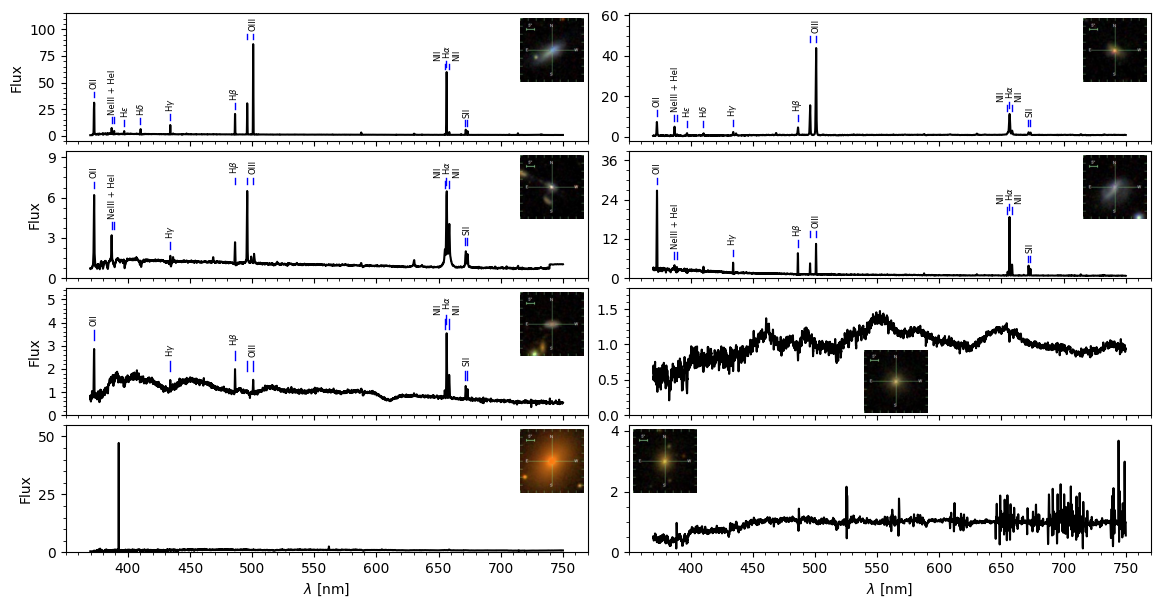

In [25]:
fig, axs = plt.subplots(
    4, 2,
    sharex=True,
    # figsize=(14, 7)
    figsize=(14, 7)
)
width_height_image = '100%'
# ------------------------------------------------------
# row 1
axs[0, 0], ax_img = spec_photo_thumbnail(
    axs[0,0],
    wave_nm, spec_overview_common_dict['narrow_line'],
    img_overview_common_dict['narrow_line'],
    width_height_image=width_height_image,
    add_image=True
)

axs[0, 0] = add_line_indicators(
    axs[0, 0], wave_nm, spec_overview_common_dict['narrow_line'],
    delta=1,
    indicator_starts=5,
    indicator_height=5,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True,
    lw=1,
    fontsize=6,
)

axs[0, 0].set_ylim(-5, 115) 
flux_ticks = range(0, 101, 25)
axs[0,0].set_yticks(flux_ticks)

## 
axs[0, 1], ax_artifact = spec_photo_thumbnail(
    axs[0, 1],
    wave_nm, spec_overview_common_dict['broad_line_large_OIII'],
    img_overview_common_dict['broad_line_large_OIII'],
    width_height_image=width_height_image,
    add_image=True
)

axs[0, 1] = add_line_indicators(
    axs[0, 1], wave_nm, spec_overview_common_dict['broad_line_large_OIII'],
    delta=1,
    indicator_starts=3,
    indicator_height=3,
    add_ne3_he1=True,
    add_h_epsilon=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True,
    lw=1,
    fontsize=6,
)

axs[0, 1].set_ylim(-2, 61)
flux_ticks = range(0, 61, 20)
axs[0, 1].set_yticks(flux_ticks)

# ---------------------------------------------- 
# row 2
axs[1, 0], ax_img = spec_photo_thumbnail(
    axs[1, 0],
    wave_nm, spec_overview_common_dict['broad_emission_dips_OIII_half'],
    img_overview_common_dict['broad_emission_dips_OIII_half'],
    width_height_image=width_height_image,
    add_image=True
)
axs[1, 0] = add_line_indicators(
    axs[1, 0], wave_nm, spec_overview_common_dict['broad_emission_dips_OIII_half'],
    indicator_starts=0.5,
    indicator_height=0.5,
    add_ne3_he1=True,
    add_h_beta=True,
    add_h_gamma=True,
    add_sii=True,
    lw=1,
    fontsize=6,
    delta=10
)

axs[1, 0].set_ylim(0, 9.5) 
flux_ticks = range(0, 10, 3)
axs[1,0].set_yticks(flux_ticks)

##
axs[1, 1], ax_star = spec_photo_thumbnail(
    axs[1, 1],
    wave_nm, spec_overview_common_dict['star_forming_step_blue_slope'],
    img_overview_common_dict['star_forming_step_blue_slope'],
    width_height_image=width_height_image,
    add_image=True
)

axs[1, 1] = add_line_indicators(
    axs[1, 1], wave_nm, spec_overview_common_dict['star_forming_step_blue_slope'],
    indicator_starts=2,
    indicator_height=2,
    add_ne3_he1=True,
    add_h_beta=True,
    add_h_gamma=True,
    add_sii=True,
    lw=1,
    fontsize=6,
    # delta=10
)

axs[1, 1].set_ylim(0, 39) 
flux_ticks = range(0, 37, 12)
axs[1, 1].set_yticks(flux_ticks)

# ----------------------------------------------
# row 3
axs[2, 0], ax_img = spec_photo_thumbnail(
    axs[2, 0],
    wave_nm, spec_overview_common_dict['blue_bump_emission'],
    img_overview_common_dict['blue_bump_emission'],
    width_height_image=width_height_image,
    add_image=True
)
axs[2, 0] = add_line_indicators(
    axs[2, 0], wave_nm, spec_overview_common_dict['blue_bump_emission'],
    indicator_starts=0.4,
    indicator_height=0.4,
    add_h_gamma=True,
    add_h_beta=True,
    add_sii=True,
    lw=1,
    fontsize=6,
)
axs[2, 0].set_ylim(0, 5.5) 
flux_ticks = range(0, 6, 1)
axs[2, 0].set_yticks(flux_ticks)

## 
axs[2, 1], ax_artifact = spec_photo_thumbnail(
    axs[2, 1],
    wave_nm, spec_overview_common_dict['passive_star'],
    img_overview_common_dict['passive_star'],
    width_height_image=width_height_image,
    bbox_to_anchor=(0.275, 0.07, 0.5, 0.5),
    add_image=True
)

axs[2, 1].set_ylim(0, 1.8) 
flux_ticks = [0, 0.5, 1, 1.5]
axs[2, 1].set_yticks(flux_ticks)

# ---------------------------------------------- 
# row 4
axs[3, 0], ax_img = spec_photo_thumbnail(
    axs[3, 0],
    wave_nm, spec_overview_common_dict['spike'],
    img_overview_common_dict['spike'],
    width_height_image=width_height_image,
    add_image=True
)

axs[3, 0].set_ylim(0, 55) 
flux_ticks = [0, 25, 50]
axs[3, 0].set_yticks(flux_ticks)

##
axs[3, 1], ax_artifact = spec_photo_thumbnail(
    axs[3, 1],
    wave_nm, spec_overview_common_dict['noise_forest'],
    img_overview_common_dict['noise_forest'],
    width_height_image=width_height_image,
    add_image=True,
    bbox_to_anchor=(-0.167, 0.52, 0.5, 0.5),
)

axs[3, 1].set_ylim(0, 4.2) 
flux_ticks = [0, 2, 4]
axs[3, 1].set_yticks(flux_ticks)

# ---------------------------------------------- 
axs[3, 0].set_xlabel(r"$\lambda$ [nm]")
axs[3, 1].set_xlabel(r"$\lambda$ [nm]")

for ax in axs.flatten(): ax.minorticks_on()
for i, ax in enumerate(axs.flatten()):
    if i%2==0:
        ax.set_ylabel("Flux")
# ---------------------------------

plt.subplots_adjust(
    hspace=0.075,
    wspace=0.078
)

# fig.savefig(
#     f"{ch_4_dir}/{bin_id}/overview_common_anomalies.pdf",
#     bbox_inches='tight'
# )


# Distinct anomalies (all scores)

In [26]:
all_scores = se_cols + rse_cols

all_unique_ids_dict, all_ids_top_dict, n_dictinct_top_all = top_unique_ids(
    scores_df=score_df.copy(),
    scores_list=all_scores,
    quantile=99,
    # n_top=1000, use_ntop=True
)

N unique: 4095
Unique to mse:
262 --> 6.3980%
Unique to mse_filter_250:
128 --> 3.1258%
Unique to mse_97:
46 --> 1.1233%
Unique to mse_filter_250_97:
61 --> 1.4896%
Unique to mse_rel:
45 --> 1.0989%
Unique to mse_filter_250_rel:
125 --> 3.0525%
Unique to mse_97_rel:
64 --> 1.5629%
Unique to mse_filter_250_97_rel:
146 --> 3.5653%


In [27]:
ensemble_diversity =  n_dictinct_top_all/(1819*8)*100
print(f"Ensemble diversity: {ensemble_diversity:.2f}%")
# --------------------------------------------------------------------
n_unique_per_score_all_all = 262 + 128 + 46 + 61 + 45 + 125 + 64 + 146
common_over_distinct = n_unique_per_score_all_all/n_dictinct_top_all*100
print(f"Common over distinct: {common_over_distinct:.2f}%")

Ensemble diversity: 28.14%
Common over distinct: 21.42%


## Select candidates

In [42]:
rank_cols = se_rank_cols + rse_rank_cols
score_rank_df.loc[
    [
       2201231682403592192, # SE 
       2203468363479410688, # Filter SE
       312016418084251648, # Trim SE
       2191010072388200448, # Filter + Trim SE
       1534667320067123200, # RSE
       2486084366183196672, # Filter RSE
       1781231151415846912, # Trim RSE
       2071695744137455616, # Trim + Filter RSE

    ],
    rank_cols
]

,rank_mse,rank_mse_filter_250,rank_mse_97,rank_mse_filter_250_97,rank_mse_rel,rank_mse_filter_250_rel,rank_mse_97_rel,rank_mse_filter_250_97_rel
specobjid,,,,,,,,
2201231682403592192,211.0,4937.0,22716.0,14223.0,2019.0,47171.0,46597.0,61172.0
2203468363479410688,2028.0,1105.0,95133.0,120174.0,7861.0,9134.0,109729.0,126633.0
312016418084251648,3492.0,2514.0,1421.0,2028.0,3422.0,3285.0,2329.0,4062.0
2191010072388200448,4367.0,1959.0,3272.0,1194.0,2702.0,3734.0,6488.0,3347.0
1534667320067123200,2701.0,12998.0,15308.0,23002.0,1172.0,11731.0,6259.0,4346.0
2486084366183196672,21876.0,17908.0,5393.0,13481.0,4533.0,991.0,2829.0,3784.0
1781231151415846912,55746.0,48354.0,29058.0,63173.0,2649.0,2750.0,666.0,4092.0
2071695744137455616,13904.0,9850.0,5340.0,5783.0,7695.0,10767.0,2121.0,828.0


In [74]:
overview_distinct_dict = {
    # row 1
    'SE': 2201231682403592192,
    'Filter SE':2203468363479410688, 
    # row 2
    'Trim SE': 312016418084251648,
    'Filter + Trim SE': 2191010072388200448,
    # row 3
    'RSE': 1534667320067123200,
    'Filter RSE': 2032375840699869184,
    # 'Filter RSE': 2486084366183196672,
    # row 4
    'Trim RSE': 1781231151415846912,
    'Filter + Trim RSE': 2486018670363437056
    # 'Filter + Trim RSE': 2071695744137455616,
}
# ----------------------------------------------------------
print('Get specs and load photometry')
# Get specs
spec_overview_distinct_dict = {}

save_to = f"{ch_4_dir}/{bin_id}/overview_distinct"
for key in overview_distinct_dict.keys():

    objid = overview_distinct_dict[key]
    spec_idx = specobjid_to_idx(
        objid, idx_id_spec
    )

    spec_overview_distinct_dict[key] = spectra[spec_idx]

    # download image and spectrum
    ra, dec = final_meta_df[['ra', 'dec']].loc[objid].values
    get_sdss_spec_img(
        specobjid=objid, ra=ra, dec=dec, save_to=save_to
    )

# Load photometry
img_overview_distinct_dict = {}

for key in overview_distinct_dict.keys():

    objid = overview_distinct_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_overview_distinct_dict[key] = img_

Get specs and load photometry


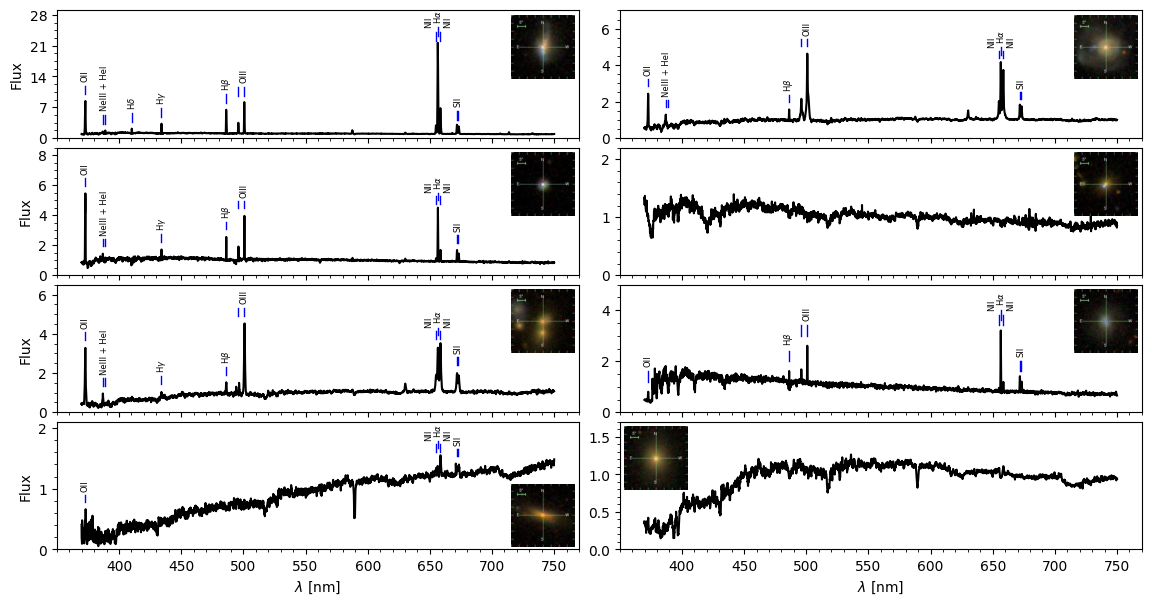

In [98]:
fig, axs = plt.subplots(
    4, 2,
    sharex=True,
    # figsize=(14, 7)
    figsize=(14, 7)
)
width_height_image = '100%'
# ------------------------------------------------------
# row 1
axs[0, 0], ax_img = spec_photo_thumbnail(
    axs[0,0],
    wave_nm, spec_overview_distinct_dict['SE'],
    img_overview_distinct_dict['SE'],
    width_height_image=width_height_image,
    add_image=True
)

axs[0, 0] = add_line_indicators(
    axs[0, 0], wave_nm, spec_overview_distinct_dict['SE'],
    delta=1,
    indicator_starts=1.5,
    indicator_height=2,
    add_oii=True,
    add_ne3_he1=True,
    add_h_delta=True,
    add_h_gamma=True,
    add_oiii=True,
    add_h_beta=True,
    add_sii=True,
    lw=1,
    fontsize=6,
)

axs[0, 0].set_ylim(0, 29) 
flux_ticks = range(0, 30, 7)
axs[0,0].set_yticks(flux_ticks)

## 
axs[0, 1], ax_artifact = spec_photo_thumbnail(
    axs[0, 1],
    wave_nm, spec_overview_distinct_dict['Filter SE'],
    img_overview_distinct_dict['Filter SE'],
    width_height_image=width_height_image,
    add_image=True
)

axs[0, 1] = add_line_indicators(
    axs[0, 1], wave_nm, spec_overview_distinct_dict['Filter SE'],
    delta=1,
    indicator_starts=0.4,
    indicator_height=0.4,
    add_oii=True,
    add_ne3_he1=True,
    add_oiii=True,
    add_h_beta=True,
    add_sii=True,
    lw=1,
    fontsize=6,
)

axs[0, 1].set_ylim(0, 7)
flux_ticks = range(0, 7, 2)
axs[0, 1].set_yticks(flux_ticks)

# ---------------------------------------------- 
# row 2
axs[1, 0], ax_img = spec_photo_thumbnail(
    axs[1, 0],
    wave_nm, spec_overview_distinct_dict['Trim SE'],
    img_overview_distinct_dict['Trim SE'],
    width_height_image=width_height_image,
    add_image=True
)

axs[1, 0] = add_line_indicators(
    axs[1, 0], wave_nm, spec_overview_distinct_dict['Trim SE'],
    indicator_starts=0.5,
    indicator_height=0.5,
    add_oii=True,
    add_ne3_he1=True,
    add_h_beta=True,
    add_oiii=True,
    add_h_gamma=True,
    add_sii=True,
    lw=1,
    fontsize=6,
    delta=10
)

axs[1, 0].set_ylim(0, 8.5) 
flux_ticks = range(0, 9, 2)
axs[1,0].set_yticks(flux_ticks)

##
axs[1, 1], ax_star = spec_photo_thumbnail(
    axs[1, 1],
    wave_nm, spec_overview_distinct_dict['Filter + Trim SE'],
    img_overview_distinct_dict['Filter + Trim SE'],
    width_height_image=width_height_image,
    add_image=True
)

axs[1, 1].set_ylim(0, 2.2) 
flux_ticks = [0, 1, 2]
axs[1, 1].set_yticks(flux_ticks)

# ----------------------------------------------
# row 3
axs[2, 0], ax_img = spec_photo_thumbnail(
    axs[2, 0],
    wave_nm, spec_overview_distinct_dict['RSE'],
    img_overview_distinct_dict['RSE'],
    width_height_image=width_height_image,
    add_image=True
)

axs[2, 0] = add_line_indicators(
    axs[2, 0], wave_nm, spec_overview_distinct_dict['RSE'],
    indicator_starts=0.4,
    indicator_height=0.4,
    add_oii=True,
    add_ne3_he1=True,
    add_h_gamma=True,
    add_h_beta=True,
    add_oiii=True,
    add_sii=True,
    lw=1,
    fontsize=6,
    delta=10
)

axs[2, 0].set_ylim(0, 6.5) 
flux_ticks = range(0, 7, 2)
axs[2, 0].set_yticks(flux_ticks)

## 
axs[2, 1], ax_artifact = spec_photo_thumbnail(
    axs[2, 1],
    wave_nm, spec_overview_distinct_dict['Filter RSE'],
    img_overview_distinct_dict['Filter RSE'],
    width_height_image=width_height_image,
    # bbox_to_anchor=(0.695, 0.07, 0.5, 0.5),
    # bbox_to_anchor=(-0.167, 0.52, 0.5, 0.5),
    add_image=True
)
axs[2, 1] = add_line_indicators(
    axs[2, 1], wave_nm, spec_overview_distinct_dict['Filter RSE'],
    indicator_starts=0.4,
    indicator_height=0.4,
    add_oii=True,
    add_h_beta=True,
    add_oiii=True,
    add_sii=True,
    lw=1,
    fontsize=6,
    # delta=10
)
axs[2, 1].set_ylim(0, 5)
flux_ticks = [0, 2, 4]
axs[2, 1].set_yticks(flux_ticks)

# ---------------------------------------------- 
# row 4
axs[3, 0], ax_img = spec_photo_thumbnail(
    axs[3, 0],
    wave_nm, spec_overview_distinct_dict['Trim RSE'],
    img_overview_distinct_dict['Trim RSE'],
    width_height_image=width_height_image,
    bbox_to_anchor=(0.695, 0.07, 0.5, 0.5),
    add_image=True
)

axs[3, 0] = add_line_indicators(
    axs[3, 0], wave_nm, spec_overview_distinct_dict['Trim RSE'],
    indicator_starts=0.12,
    indicator_height=0.12,
    add_oii=True,
    add_sii=True,
    lw=1,
    fontsize=6,
    delta=10
)

axs[3, 0].set_ylim(0, 2.1) 
flux_ticks = [0, 1, 2]
axs[3, 0].set_yticks(flux_ticks)

##
axs[3, 1], ax_artifact = spec_photo_thumbnail(
    axs[3, 1],
    wave_nm, spec_overview_distinct_dict['Filter + Trim RSE'],
    img_overview_distinct_dict['Filter + Trim RSE'],
    width_height_image=width_height_image,
    add_image=True,
    bbox_to_anchor=(-0.167, 0.52, 0.5, 0.5),
)

axs[3, 1].set_ylim(0, 1.7) 
flux_ticks = [0, 0.5, 1, 1.5]
axs[3, 1].set_yticks(flux_ticks)

# ---------------------------------------------- 
axs[3, 0].set_xlabel(r"$\lambda$ [nm]")
axs[3, 1].set_xlabel(r"$\lambda$ [nm]")

for ax in axs.flatten(): ax.minorticks_on()
for i, ax in enumerate(axs.flatten()):
    if i%2==0:
        ax.set_ylabel("Flux")
# ---------------------------------

plt.subplots_adjust(
    hspace=0.075,
    wspace=0.078
)

fig.savefig(
    f"{ch_4_dir}/{bin_id}/overview_distinct_anomalies.pdf",
    bbox_inches='tight'
)


## median specs

In [29]:
spec_idx_unique_dict = {}

for score, objids in all_unique_ids_dict.items():
    
    idx_list = []
    for objid in objids:

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        idx_list.append(spec_idx)

    spec_idx_unique_dict[score] = idx_list

In [31]:
median_specs_dict = {}
mean_specs_dict = {}

for score, idx_list in spec_idx_unique_dict.items():
    specs = spectra[idx_list, :]
    median_specs_dict[score] = np.nanmedian(specs, axis=0)
    mean_specs_dict[score] = np.nanmean(specs, axis=0)

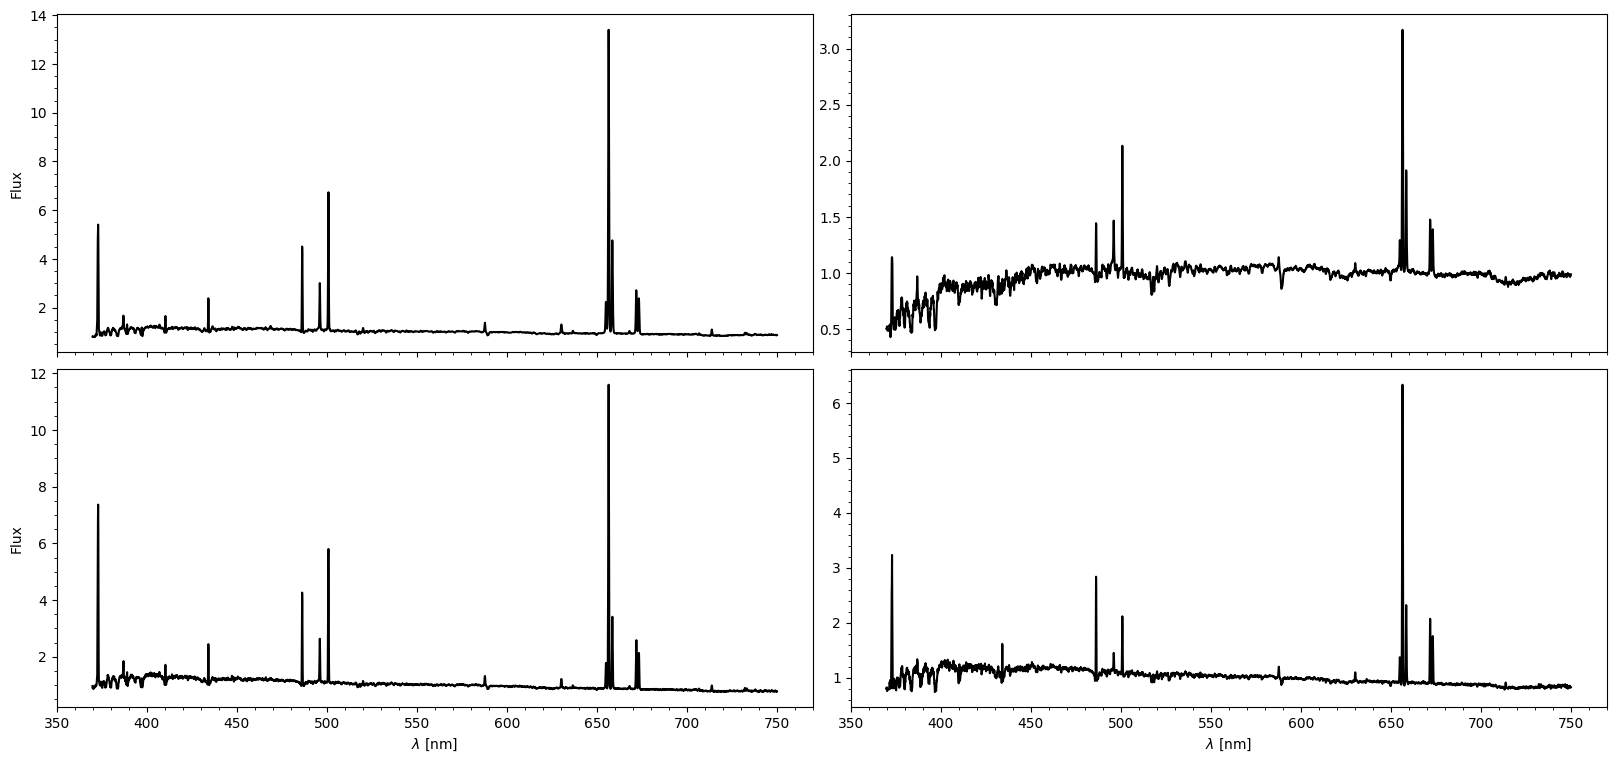

In [36]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, median_specs_dict['mse'], color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, median_specs_dict['mse_filter_250'], color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, median_specs_dict['mse_97'], color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, median_specs_dict['mse_filter_250_97'], color='black')
# ------------------------------------------------------
# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)

scores_names = ["SE", "Filtered SE", "Trimmed SE", "Filtered + Trimmed SE"]
# set minor ticks on
for ax, score in zip(axs.flatten(), scores_names):
    ax.minorticks_on()

    # if score == "SE":
    #     y_ticks = [0, 3, 6, 9, 12]
    #     ax.set_ylim(0, 12.5)
    # elif score == "Filtered SE":
    #     y_ticks = [0, 3, 6, 9]
    #     ax.set_ylim(0, 9.5)
    # elif score == "Trimmed SE":
    #     y_ticks = [0, 3, 6, 9]
    #     ax.set_ylim(0, 10)
    # else:  # Filtered + Trimmed RSE
    #     y_ticks = [0, 3, 6, 9]
    #     ax.set_ylim(0, 10)

    # ax.set_yticks(y_ticks)

    # ax.text(
    #     0.02, 0.95,
    #     f" Median spectrum of top 1% anomalies for {score} score",
    #     horizontalalignment="left", verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=12
    # )

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel("Flux")
# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)


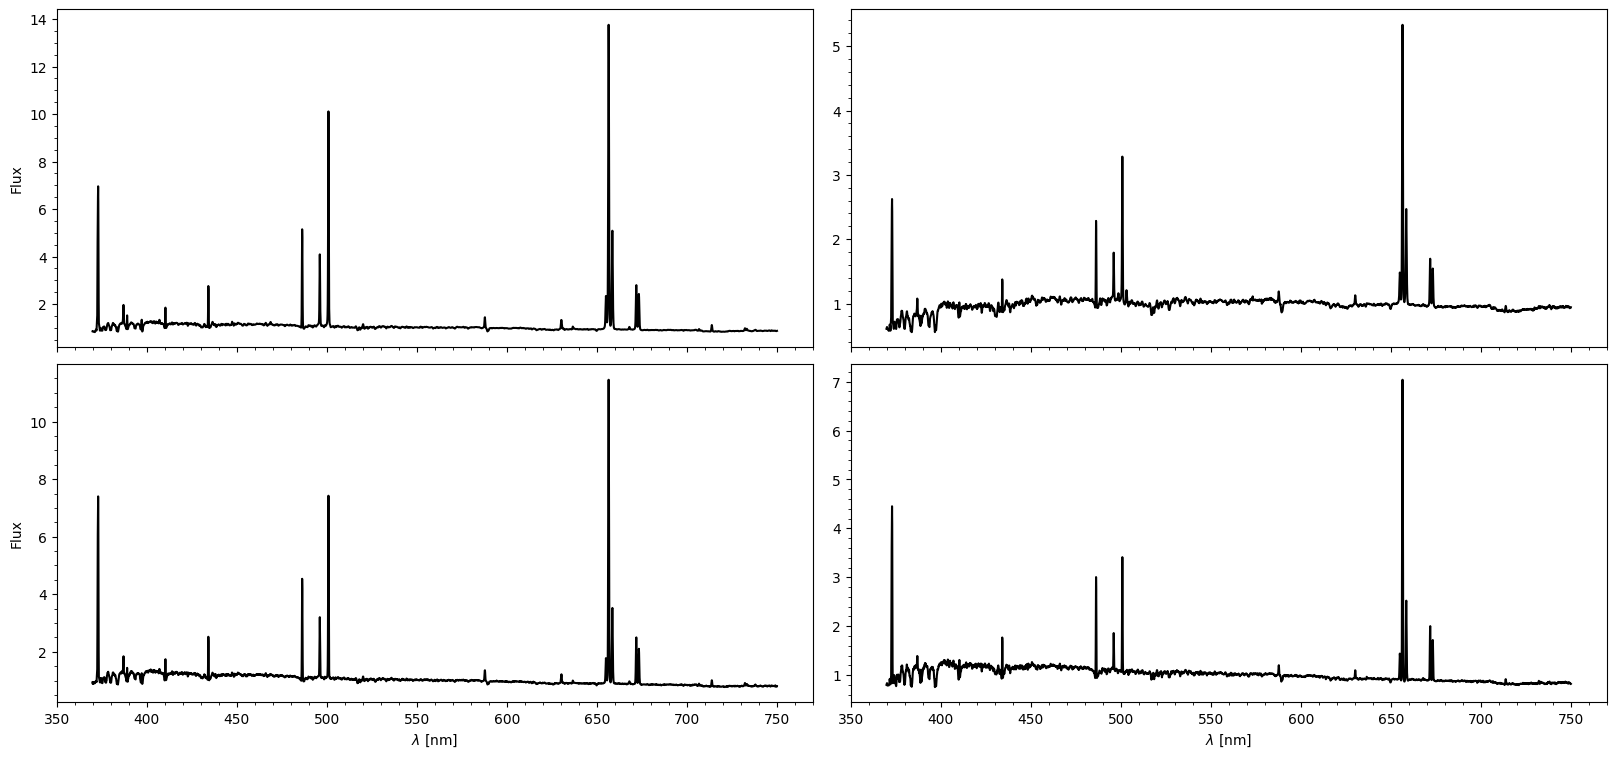

In [37]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, mean_specs_dict['mse'], color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, mean_specs_dict['mse_filter_250'], color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, mean_specs_dict['mse_97'], color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, mean_specs_dict['mse_filter_250_97'], color='black')
# ------------------------------------------------------
# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)

scores_names = ["SE", "Filtered SE", "Trimmed SE", "Filtered + Trimmed SE"]
# set minor ticks on
for ax, score in zip(axs.flatten(), scores_names):
    ax.minorticks_on()

    # if score == "SE":
    #     y_ticks = [0, 3, 6, 9, 12]
    #     ax.set_ylim(0, 12.5)
    # elif score == "Filtered SE":
    #     y_ticks = [0, 3, 6, 9]
    #     ax.set_ylim(0, 9.5)
    # elif score == "Trimmed SE":
    #     y_ticks = [0, 3, 6, 9]
    #     ax.set_ylim(0, 10)
    # else:  # Filtered + Trimmed RSE
    #     y_ticks = [0, 3, 6, 9]
    #     ax.set_ylim(0, 10)

    # ax.set_yticks(y_ticks)

    # ax.text(
    #     0.02, 0.95,
    #     f" Median spectrum of top 1% anomalies for {score} score",
    #     horizontalalignment="left", verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=12
    # )

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel("Flux")
# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)


# old code

# Distinct IDs

## SE family

In [14]:
se_unique_ids_dict, se_ids_top_dict, n_dictinct_top_se = top_unique_ids(
    scores_df=score_df.copy(),
    scores_list=se_cols,
    quantile=99,
    n_top=None, use_ntop=False
)

N unique: 3173
Unique to mse:
433 --> 13.6464%
Unique to mse_filter_250:
261 --> 8.2257%
Unique to mse_97:
63 --> 1.9855%
Unique to mse_filter_250_97:
143 --> 4.5068%


In [15]:
n_dictinct_top_se/(1819*4)*100

43.60912589334799

In [16]:
n_unique_per_score_all = 433 + 261 + 63 + 143
n_unique_per_score_all/n_dictinct_top_se*100

28.364323983611722

## RSE family

In [17]:
rse_unique_ids_dict, rse_ids_top_dict, n_dictinct_top_rse = top_unique_ids(
    scores_df=score_df.copy(),
    scores_list=rse_cols,
    quantile=99,
    # n_top=1000, use_ntop=True
)

N unique: 3107
Unique to mse_rel:
309 --> 9.9453%
Unique to mse_filter_250_rel:
190 --> 6.1152%
Unique to mse_97_rel:
158 --> 5.0853%
Unique to mse_filter_250_97_rel:
177 --> 5.6968%


In [18]:
n_dictinct_top_rse/(1819*4)*100

42.702034084661896

In [19]:
n_unique_per_score_all_rse = 309 + 190 + 158 + 177
n_unique_per_score_all_rse/n_dictinct_top_rse*100

26.842613453492113

# Common IDs

## SE family

In [23]:
se_common_ids, se_ids_top_dict, n_dictinct_se, n_common_se = top_common_ids(
    scores_df=score_df.copy(), scores_list=se_cols,
    quantile=99,
    n_top=None, use_ntop=False
)

N unique: 3173
N common:
692 -- > 21.809014%


In [24]:
n_dictinct_se, n_common_se

(3173, 692)

## RSE Family

In [26]:
rse_common_ids, res_ids_top_dict, n_dictinct_rse, n_common_rse = top_common_ids(
    scores_df=score_df.copy(), scores_list=rse_cols,
    quantile=99,
    n_top=None, use_ntop=False
)

N unique: 3107
N common:
789 -- > 25.394271%


In [27]:
n_dictinct_rse, n_common_rse

(3107, 789)